# Preprocessing Overview

## Model Pipeline

This notebook prepares data for a **two-stage model pipeline**:

1. **Classification model** — predicts whether a signal is LOS (0) or NLOS (1)
2. **Regression model** — predicts the true range (distance), using the classifier's NLOS prediction as an additional input feature

The classifier runs first; its output is appended to the feature set before passing into the regressor.

---

## Dataset Splits

### Classification
| Variable | Shape | Description |
|---|---|---|
| `X_train_classification` | (33,600 × 102) | Training features: scaled non-CIR signal features + 86 PCA components of CIR |
| `X_test_classification` | (8,400 × 102) | Test features: same transformation applied to held-out data |
| `y_train` | (33,600,) | Training labels — NLOS binary flag (0 = LOS, 1 = NLOS) |
| `y_test` | (8,400,) | Test labels — NLOS binary flag |

### Regression
| Variable | Shape | Description |
|---|---|---|
| `X_train_reg` | (33,600 × 103) | `X_train_classification` + true NLOS label appended as an extra feature |
| `X_test_reg` | (8,400 × 103) | `X_test_classification` + true NLOS label appended as an extra feature |
| `y_reg_train` | (33,600,) | Training targets — measured range in metres |
| `y_reg_test` | (8,400,) | Test targets — measured range in metres |

> **80/20 train-test split**, stratified on the NLOS label to preserve class balance.

---

## Regression Evaluation Strategy

Both `X_train_reg` and `X_test_reg` use the **true NLOS labels** (not classifier predictions) as the appended feature. This is a deliberate choice to **evaluate the regression model in isolation** — decoupled from any classification errors.

This gives the regression model's **upper-bound performance**: the best it can achieve assuming perfect upstream classification. It answers the question:

> *"Given a correct NLOS label, how accurately can the model predict range?"*

End-to-end evaluation (classifier → regressor with predicted NLOS labels) is handled separately in the modelling notebook, where the two models are composed and evaluated as a full pipeline.

---

## End-to-End Pipeline Evaluation

To evaluate the full pipeline as it would behave in production, the two models must be composed in sequence using `X_test_classification` as the sole input:

```python
# 1. Classifier predicts NLOS on the held-out test set
nlos_pred_test = classifier.predict(X_test_classification)

# 2. Append predicted NLOS label to form the regression input
X_test_reg_e2e = np.hstack([X_test_classification, nlos_pred_test.reshape(-1, 1)])

# 3. Regressor predicts range using the composed feature set
range_pred = regressor.predict(X_test_reg_e2e)
```

This end-to-end evaluation captures the **real-world error profile** — any misclassification by the classifier propagates into the regressor, producing a realistic picture of deployed performance. Comparing these metrics against the isolated regression metrics quantifies how much the classification errors degrade range accuracy.


In [2]:
import numpy as np
import pandas as pd
import uwb_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

data = uwb_dataset.import_from_files()  # numpy array

# column names based on CSV format
base_cols = [
    "NLOS","RANGE","FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","CIR_PWR","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR"
]
cir_cols = [f"CIR{i}" for i in range(1016)]
cols = base_cols + cir_cols

df = pd.DataFrame(data, columns=cols)
df.head()

../dataset/uwb_dataset_part2.csv
../dataset/uwb_dataset_part3.csv
../dataset/uwb_dataset_part1.csv
../dataset/uwb_dataset_part4.csv
../dataset/uwb_dataset_part5.csv
../dataset/uwb_dataset_part7.csv
../dataset/uwb_dataset_part6.csv


,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR1006,CIR1007,CIR1008,CIR1009,CIR1010,CIR1011,CIR1012,CIR1013,CIR1014,CIR1015
0,1.0,6.18,749.0,4889.0,13876.0,10464.0,240.0,9048.0,3668.0,1024.0,...,0.798828,0.916016,0.574219,0.270508,0.709961,0.358398,0.784180,0.799805,0.456055,0.75
1,1.0,4.54,741.0,2474.0,2002.0,1593.0,68.0,6514.0,1031.0,1024.0,...,0.282227,0.222656,0.104492,0.475586,0.479492,0.394531,0.326172,0.205078,0.099609,0.00
2,1.0,4.39,744.0,1934.0,2615.0,4114.0,52.0,2880.0,796.0,1024.0,...,0.120117,0.274414,0.471680,0.094727,0.265625,0.071289,0.122070,0.165039,0.177734,0.00
3,1.0,1.27,748.0,16031.0,17712.0,10420.0,64.0,12855.0,1529.0,323.0,...,0.523220,0.427245,0.678019,0.291022,0.696594,0.479876,0.532508,0.860681,0.984520,0.00
4,0.0,1.16,743.0,20070.0,19886.0,15727.0,76.0,11607.0,2022.0,296.0,...,0.293919,0.145270,1.209459,1.040541,0.445946,0.442568,0.344595,0.425676,0.550676,0.00


In [3]:
WINDOW_SIZE = 200
LEAD        = 10  

cir_array  = df[cir_cols].to_numpy()
fp_indices = df["FP_IDX"].to_numpy().astype(int)

windowed = np.zeros((len(df), WINDOW_SIZE))

for i in range(len(df)):
    fp_idx = fp_indices[i]
    start  = max(0, fp_idx - LEAD)
    end    = min(1016, start + WINDOW_SIZE)
    actual_size               = end - start
    windowed[i, :actual_size] = cir_array[i, start:end]

df          = df.drop(columns=cir_cols)
cir_cols    = [f"CIR_{i}" for i in range(WINDOW_SIZE)]  
windowed_df = pd.DataFrame(windowed, columns=cir_cols, index=df.index)
df          = pd.concat([df, windowed_df], axis=1)

# Verify
print(f"Windowed array shape: {windowed.shape}")
print(f"New df shape: {df.shape}")
print(f"All zero rows: {(windowed == 0).all(axis=1).sum()}")


Windowed array shape: (42000, 200)
New df shape: (42000, 215)
All zero rows: 0


Basic Cleaning/Validation

In [4]:
print("Missing values:", df.isna().sum().sum())
print("Duplicates:", df.duplicated().sum())

#drop duplicates if any
df = df.drop_duplicates()

Missing values: 0
Duplicates: 0


In [ ]:
impossible_mask = (
    (df["RANGE"]   <= 0) |   # distance must be positive
    (df["RXPACC"]  <= 0) |   # preamble accumulation count must be positive
    (df["FP_AMP1"] <  0) |   # amplitudes cannot be negative
    (df["FP_AMP2"] <  0) |
    (df["FP_AMP3"] <  0) |
    (df["FP_IDX"]  <  0)    # sample index cannot be negative
)

n_impossible = impossible_mask.sum()
print(f"Physically impossible rows: {n_impossible} ({100 * n_impossible / len(df):.3f}%)")

if n_impossible > 0:
    print(df[impossible_mask][["RANGE","RXPACC","FP_AMP1","FP_AMP2","FP_AMP3","FP_IDX"]].head(10))
    df = df[~impossible_mask].reset_index(drop=True)
    print(f"Rows after removal: {len(df)}")
else:
    print("No physically impossible values found — dataset is clean.")

Physically impossible rows: 1 (0.002%)
       RANGE  RXPACC  FP_AMP1  FP_AMP2  FP_AMP3  FP_IDX
29009    0.0   265.0  17559.0  17926.0  11004.0   744.0
Rows after removal: 41999


This checks for outliers in the 10 raw base columns from the original dataset — the non-CIR signal/hardware metadata columns that exist before any feature engineering. No need to remove them as they are meaningful

Feature                  Q1         Q3        IQR      Lower      Upper   Outliers      %
--------------------------------------------------------------------------------------
RANGE                  1.81       5.42       3.61      -3.60      10.84        121   0.29%
FP_IDX               744.00     748.00       4.00     738.00     754.00      1,757   4.18%
FP_AMP1             3573.50   12273.00    8699.50   -9475.75   25322.25          0   0.00%
FP_AMP2             5322.50   17309.50   11987.00  -12658.00   35290.00          0   0.00%
FP_AMP3             4723.00   14256.00    9533.00   -9576.50   28555.50          0   0.00%
STDEV_NOISE           56.00      80.00      24.00      20.00     116.00      1,915   4.56%
CIR_PWR             6727.00   12443.00    5716.00   -1847.00   21017.00        938   2.23%
MAX_NOISE            961.00    1488.00     527.00     170.50    2278.50      2,965   7.06%
RXPACC               318.00    1024.00     706.00    -741.00    2083.00          0   0.00%


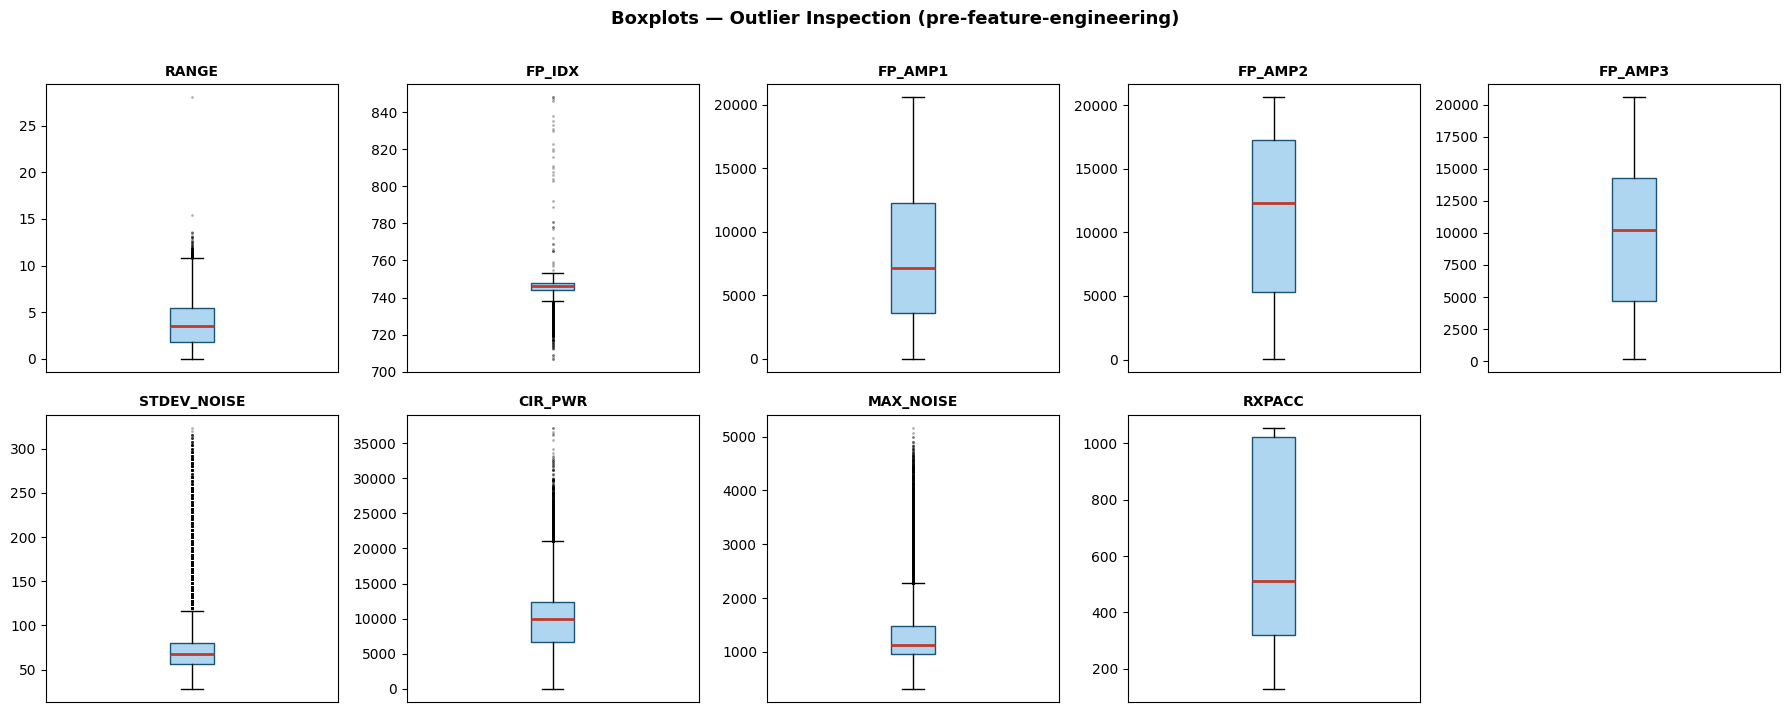

In [6]:

import matplotlib.pyplot as plt

numeric_cols = [
    "RANGE", "FP_IDX", "FP_AMP1", "FP_AMP2", "FP_AMP3",
    "STDEV_NOISE", "CIR_PWR", "MAX_NOISE", "RXPACC"
]

# ── IQR outlier count per feature ────────────────────────────────────────────
print(f"{'Feature':<16} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>10} {'Upper':>10} {'Outliers':>10} {'%':>6}")
print("-" * 86)
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = 100 * n_out / len(df)
    print(f"{col:<16} {q1:>10.2f} {q3:>10.2f} {iqr:>10.2f} {lower:>10.2f} {upper:>10.2f} {n_out:>10,} {pct:>6.2f}%")

# ── Boxplots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#AED6F1", color="#1A5276"),
               medianprops=dict(color="#C0392B", linewidth=2),
               flierprops=dict(marker=".", markersize=2, alpha=0.3, color="#717D7E"))
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xticks([])

# hide unused subplot
for ax in axes[len(numeric_cols):]:
    ax.set_visible(False)

plt.suptitle("Boxplots — Outlier Inspection (pre-feature-engineering)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


feature engineering

In [7]:
from scipy.stats import kurtosis as sp_kurtosis

# FP "power" aggregate
df["FP_POWER"] = (df["FP_AMP1"]**2 + df["FP_AMP2"]**2 + df["FP_AMP3"]**2)

# Simple CIR summary stats (fast, useful)
cir = df[cir_cols].to_numpy()
df["CIR_MEAN"] = cir.mean(axis=1)
df["CIR_MAX"]  = cir.max(axis=1)
df["CIR_ENERGY"] = (cir**2).mean(axis=1)  # average energy

delays = np.arange(200)
power = cir ** 2
mean_delay = (delays * power).sum(axis=1) / power.sum(axis=1)
rms_ds = np.sqrt(((delays - mean_delay[:, None])**2 * power).sum(axis=1) /
power.sum(axis=1))
df["RMS_DELAY_SPREAD"] = rms_ds


df["FP_RSS"]  = 10 * np.log10(df["FP_POWER"]  / (df["RXPACC"]**2) + 1e-9)
df["CIR_RSS"] = 10 * np.log10(df["CIR_PWR"] * 2**17 / (df["RXPACC"]**2) + 1e-9)
df["FP_CIR_RATIO_dB"] = df["FP_RSS"] - df["CIR_RSS"]

# Rise time: distance from first path to CIR peak (NLOS → larger rise time)
peak_idx = np.argmax(cir, axis=1)
df["RISE_TIME"] = peak_idx - LEAD

# CIR kurtosis: LOS → sharp spike (high), NLOS → spread (low)
df["CIR_KURTOSIS"] = sp_kurtosis(cir, axis=1, fisher=True)

# Early-late energy ratio: NLOS has proportionally more late energy
mid = WINDOW_SIZE // 2
early_energy = (cir[:, :mid] ** 2).sum(axis=1)
late_energy  = (cir[:, mid:] ** 2).sum(axis=1)
df["EARLY_LATE_RATIO"] = 10 * np.log10(early_energy / (late_energy + 1e-9))

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,FP_AMP3,STDEV_NOISE,CIR_PWR,MAX_NOISE,RXPACC,...,CIR_MEAN,CIR_MAX,CIR_ENERGY,RMS_DELAY_SPREAD,FP_RSS,CIR_RSS,FP_CIR_RATIO_dB,RISE_TIME,CIR_KURTOSIS,EARLY_LATE_RATIO
0,1.0,6.18,749.0,4889.0,13876.0,10464.0,240.0,9048.0,3668.0,1024.0,...,1.328721,18.063477,7.179700,26.183920,24.925391,30.534626,-5.609235,4,24.116298,14.947883
1,1.0,4.54,741.0,2474.0,2002.0,1593.0,68.0,6514.0,1031.0,1024.0,...,0.956118,13.740234,4.419092,14.044151,10.820509,29.107578,-18.287069,8,20.853861,21.719441
2,1.0,4.39,744.0,1934.0,2615.0,4114.0,52.0,2880.0,796.0,1024.0,...,0.823608,7.645508,2.060393,23.687479,14.187893,25.563025,-11.375132,4,10.261955,16.141812
3,1.0,1.27,748.0,16031.0,17712.0,10420.0,64.0,12855.0,1529.0,323.0,...,2.775217,65.857585,86.415936,8.182123,38.136465,42.081770,-3.945304,3,26.115172,25.685373
4,0.0,1.16,743.0,20070.0,19886.0,15727.0,76.0,11607.0,2022.0,296.0,...,3.797382,71.388514,105.011061,12.137747,40.767807,42.396465,-1.628658,2,27.433256,22.992747
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41994,0.0,4.09,745.0,1106.0,6951.0,6283.0,88.0,10076.0,1856.0,340.0,...,3.989191,49.488235,62.791435,17.181093,28.865089,40.578403,-11.713313,7,15.733275,20.229353
41995,0.0,2.18,744.0,14870.0,13482.0,8864.0,44.0,12604.0,781.0,416.0,...,2.857680,48.288462,51.167367,12.305938,34.443661,39.798317,-5.354656,4,27.000268,22.545653
41996,0.0,1.25,748.0,18329.0,17722.0,10731.0,60.0,10192.0,1600.0,270.0,...,3.634796,69.644444,98.328866,10.963500,40.210337,42.630418,-2.420081,2,26.005051,23.735680
41997,0.0,3.17,747.0,3654.0,18470.0,17737.0,64.0,12018.0,967.0,789.0,...,1.503035,23.038023,13.341668,14.611293,30.313330,34.031881,-3.718551,1,23.416231,20.581350


Splitting of data into training and test set (80 : 20)

In [8]:
y_classification = df["NLOS"].astype(int).to_numpy()
y_regression = df["RANGE"].to_numpy()

non_cir_features = [
    "FP_IDX","FP_AMP1","FP_AMP2","FP_AMP3",
    "STDEV_NOISE","MAX_NOISE","RXPACC","CH",
    "FRAME_LEN","PREAM_LEN","BITRATE","PRFR",
    "CIR_MEAN","CIR_MAX","CIR_ENERGY", "RMS_DELAY_SPREAD","FP_RSS","CIR_RSS","FP_CIR_RATIO_dB",
    "RISE_TIME","CIR_KURTOSIS","EARLY_LATE_RATIO"
]

X_non_cir = df[non_cir_features].to_numpy()   # (42000, 22)
X_cir     = df[cir_cols].to_numpy()            # (42000, 200)
X_raw     = np.hstack([X_non_cir, X_cir])      # (42000, 222)

X_train_raw, X_test_raw, y_train, y_test, y_reg_train, y_reg_test = train_test_split(
      X_raw, y_classification, y_regression,
      test_size=0.2, random_state=42, stratify=y_classification
  )

print(f"Train: {X_train_raw.shape}")
print(f"Test:  {X_test_raw.shape}")
print(f"y_reg_train:  {y_reg_train.shape}")
print(f"y_reg_test:   {y_reg_test.shape}")

Train: (33599, 222)
Test:  (8400, 222)
y_reg_train:  (33599,)
y_reg_test:   (8400,)


Feature Importance Ranking (model-agnostic) (classification)

/var/folders/z2/hkp7bywx4s55cf4t53l831x40000gn/T/ipykernel_2061/682443535.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs(spearmanr(X_fi[:, i], y_fi).statistic)


Rank  Feature               MI Score    Spearman |r|   RF Importance
1     CIR_ENERGY              0.3394          0.7257          0.1711
2     CIR_RSS                 0.3378          0.7258          0.1250
3     CIR_MAX                 0.3286          0.7119          0.1527
4     RXPACC                  0.3191          0.7053          0.1183
5     FP_RSS                  0.3099          0.6922          0.1001
6     CIR_MEAN                0.3072          0.7030          0.0886
7     EARLY_LATE_RATIO        0.2060          0.5417          0.0399
8     RMS_DELAY_SPREAD        0.1892          0.5279          0.0478
9     FP_AMP3                 0.1550          0.5067          0.0259
10    FP_AMP2                 0.1488          0.5106          0.0225
11    MAX_NOISE               0.1423          0.1764          0.0295
12    FP_AMP1                 0.1153          0.4491          0.0136
13    FP_IDX                  0.0984          0.3415          0.0073
14    STDEV_NOISE             0.09

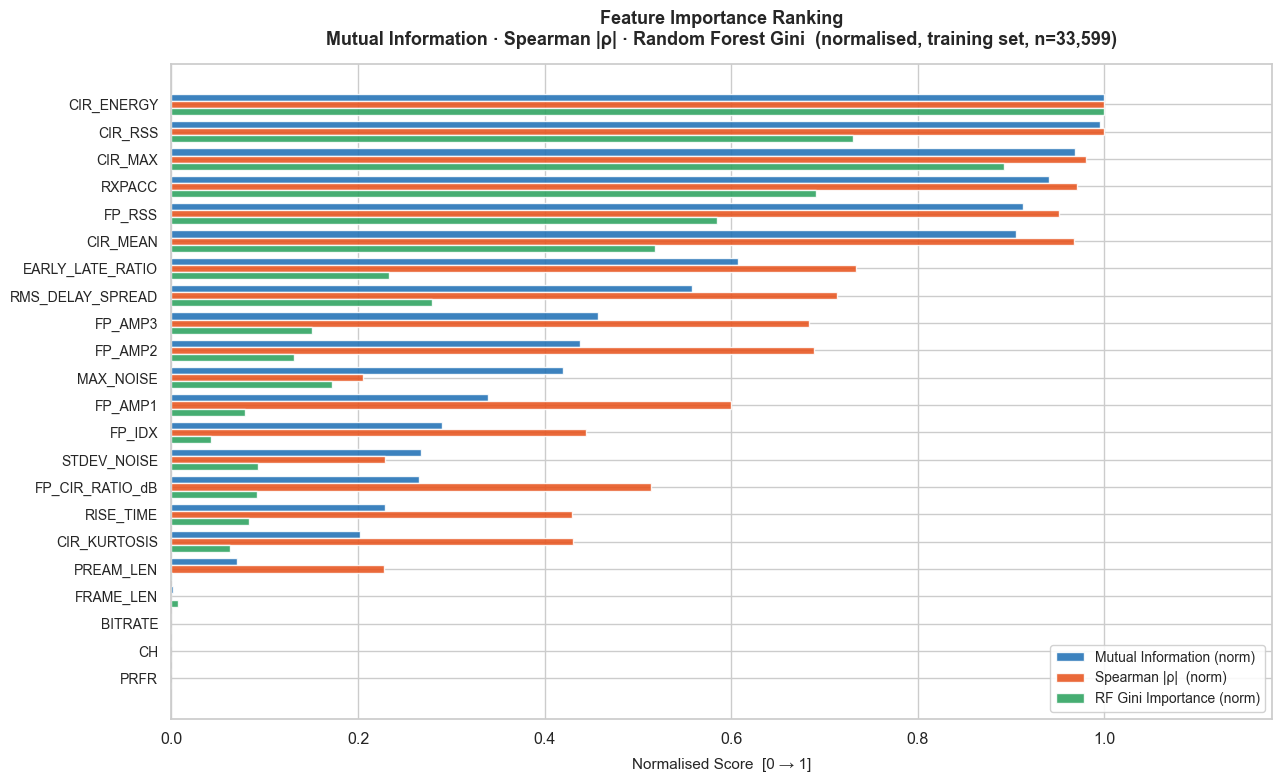

In [9]:

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

n_non_cir = len(non_cir_features)

# Training set only — never touch test data during preprocessing decisions
X_fi = X_train_raw[:, :n_non_cir]
y_fi = y_train

# ── 1. Mutual Information ──────────────────────────────────────────────────────
# Discrete hardware-config features must use the exact discrete entropy estimator,
# not the kNN continuous estimator (which inflates MI for low-cardinality features).
discrete_features_set = {"CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"}
discrete_mask = [f in discrete_features_set for f in non_cir_features]

mi_scores = mutual_info_classif(
    X_fi, y_fi, discrete_features=discrete_mask, random_state=42, n_neighbors=5
)

# ── 2. Spearman |ρ| ────────────────────────────────────────────────────────────
# Captures monotonic relationships — scale-invariant cross-check.
# spearmanr returns NaN for constant/near-constant features; we keep those as NaN
# so they don't corrupt normalization for other features.
spearman_r = np.array([
    abs(spearmanr(X_fi[:, i], y_fi).statistic)
    for i in range(X_fi.shape[1])
], dtype=float)

# ── 3. Random Forest Gini Importance ──────────────────────────────────────────
# Shallow forest — purpose is ranking only, NOT final model selection
rf = RandomForestClassifier(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf.fit(X_fi, y_fi)
rf_importance = rf.feature_importances_

# ── 4. Normalise all three to [0, 1] for fair visual comparison ───────────────
# nanmin/nanmax so that NaN entries in spearman_r don't corrupt the whole array.
def norm(arr):
    arr = np.asarray(arr, dtype=float)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

# ── 5. Ranked DataFrame (primary sort: MI Score) ──────────────────────────────
fi_df = (
    pd.DataFrame({
        "Feature"        : non_cir_features,
        "MI Score"       : mi_scores,
        "Spearman |r|"   : spearman_r,
        "RF Importance"  : rf_importance,
        "MI (norm)"      : norm(mi_scores),
        "Spearman (norm)": norm(spearman_r),
        "RF (norm)"      : norm(rf_importance),
    })
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
fi_df.index += 1  # 1-based rank

# ── 6. Print ranked table ─────────────────────────────────────────────────────
print("=" * 74)
print(f"{'Rank':<6}{'Feature':<18}{'MI Score':>12}{'Spearman |r|':>16}{'RF Importance':>16}")
print("=" * 74)
for rank, row in fi_df.iterrows():
    sp = f"{row['Spearman |r|']:>16.4f}" if not np.isnan(row['Spearman |r|']) else f"{'—':>16}"
    print(f"{rank:<6}{row['Feature']:<18}{row['MI Score']:>12.4f}{sp}{row['RF Importance']:>16.4f}")
print("=" * 74)

# ── 7. Grouped bar chart — all three metrics normalised to [0, 1] ─────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 8))

features_sorted = fi_df["Feature"].tolist()[::-1]
mi_norm  = fi_df["MI (norm)"].tolist()[::-1]
sp_norm  = fi_df["Spearman (norm)"].tolist()[::-1]
rf_norm  = fi_df["RF (norm)"].tolist()[::-1]

y_pos  = np.arange(len(fi_df))
h      = 0.26  # bar height

ax.barh(y_pos + h,  mi_norm, h, color="#2171B5", alpha=0.88, label="Mutual Information (norm)")
ax.barh(y_pos,      sp_norm, h, color="#E8541E", alpha=0.88, label="Spearman |ρ|  (norm)")
ax.barh(y_pos - h,  rf_norm, h, color="#2CA25F", alpha=0.88, label="RF Gini Importance (norm)")

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)
ax.set_xlabel("Normalised Score  [0 → 1]", fontsize=11, labelpad=8)
ax.set_xlim(0, 1.18)
ax.set_title(
    "Feature Importance Ranking\n"
    "Mutual Information · Spearman |ρ| · Random Forest Gini  "
    f"(normalised, training set, n={len(X_fi):,})",
    fontsize=13, fontweight="bold", pad=14,
)
ax.legend(loc="lower right", framealpha=0.88, fontsize=10)

plt.tight_layout()
plt.show()


Feature Importance Ranking (Regression — RANGE target)

/var/folders/z2/hkp7bywx4s55cf4t53l831x40000gn/T/ipykernel_2061/1770433424.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs(spearmanr(X_fi[:, i], y_fi_reg).statistic)


Rank  Feature               MI Score    Spearman |r|   RF Importance
1     CIR_ENERGY              0.4205          0.6847          0.0160
2     CIR_RSS                 0.4077          0.6857          0.0849
3     RXPACC                  0.3789          0.6891          0.0623
4     CIR_MAX                 0.3763          0.6924          0.4730
5     FP_RSS                  0.3423          0.6679          0.0188
6     CIR_MEAN                0.3269          0.5661          0.0746
7     RMS_DELAY_SPREAD        0.2376          0.5747          0.0871
8     MAX_NOISE               0.2145          0.2545          0.0154
9     EARLY_LATE_RATIO        0.1923          0.5189          0.0102
10    CIR_KURTOSIS            0.1717          0.4098          0.0468
11    FP_AMP2                 0.1524          0.4676          0.0049
12    FP_AMP1                 0.1523          0.4626          0.0057
13    FP_AMP3                 0.1378          0.4460          0.0046
14    FP_CIR_RATIO_dB         0.12

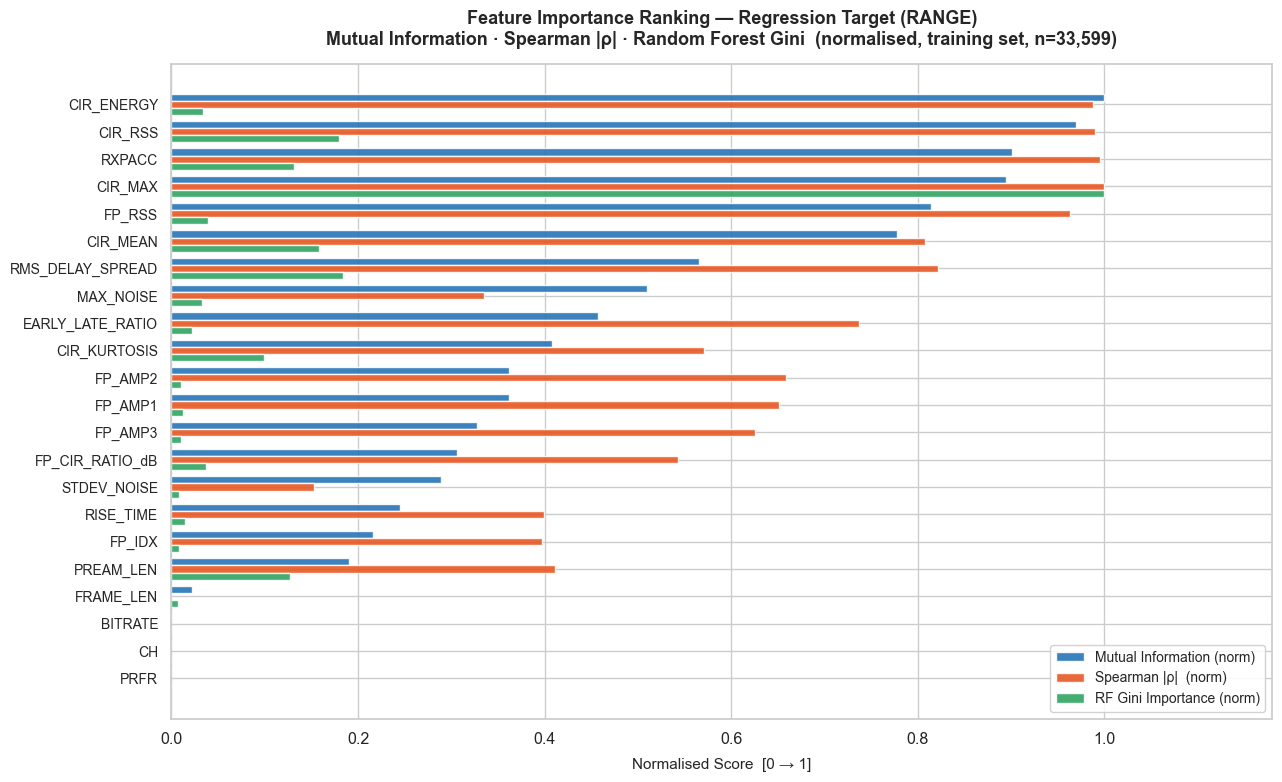

In [10]:

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

n_non_cir = len(non_cir_features)

X_fi = X_train_raw[:, :n_non_cir]
y_fi_reg = y_reg_train

# Same discrete mask as the classification cell
discrete_features_set = {"CH", "FRAME_LEN", "PREAM_LEN", "BITRATE", "PRFR"}
discrete_mask = np.array([f in discrete_features_set for f in non_cir_features], dtype=bool)

# ── 1. Mutual Information (regression) ────────────────────────────────────────
mi_scores_reg = mutual_info_regression(
    X_fi, y_fi_reg, discrete_features=discrete_mask, random_state=42, n_neighbors=5
)

# ── 2. Spearman |ρ| ────────────────────────────────────────────────────────────
spearman_r_reg = np.array([
    abs(spearmanr(X_fi[:, i], y_fi_reg).statistic)
    for i in range(X_fi.shape[1])
], dtype=float)

# ── 3. Random Forest Gini Importance (regression) ─────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10, n_jobs=-1, random_state=42)
rf_reg.fit(X_fi, y_fi_reg)
rf_importance_reg = rf_reg.feature_importances_

# ── 4. NaN-safe normalisation ─────────────────────────────────────────────────
def norm(arr):
    arr = np.asarray(arr, dtype=float)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

# ── 5. Ranked DataFrame (primary sort: MI Score) ──────────────────────────────
fi_reg_df = (
    pd.DataFrame({
        "Feature"        : non_cir_features,
        "MI Score"       : mi_scores_reg,
        "Spearman |r|"   : spearman_r_reg,
        "RF Importance"  : rf_importance_reg,
        "MI (norm)"      : norm(mi_scores_reg),
        "Spearman (norm)": norm(spearman_r_reg),
        "RF (norm)"      : norm(rf_importance_reg),
    })
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
fi_reg_df.index += 1  # 1-based rank

# ── 6. Print ranked table ─────────────────────────────────────────────────────
print("=" * 74)
print(f"{'Rank':<6}{'Feature':<18}{'MI Score':>12}{'Spearman |r|':>16}{'RF Importance':>16}")
print("=" * 74)
for rank, row in fi_reg_df.iterrows():
    sp = f"{row['Spearman |r|']:>16.4f}" if not np.isnan(row['Spearman |r|']) else f"{'—':>16}"
    print(f"{rank:<6}{row['Feature']:<18}{row['MI Score']:>12.4f}{sp}{row['RF Importance']:>16.4f}")
print("=" * 74)

# ── 7. Grouped bar chart ──────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 8))

features_sorted = fi_reg_df["Feature"].tolist()[::-1]
mi_norm  = fi_reg_df["MI (norm)"].tolist()[::-1]
sp_norm  = fi_reg_df["Spearman (norm)"].tolist()[::-1]
rf_norm  = fi_reg_df["RF (norm)"].tolist()[::-1]

y_pos = np.arange(len(fi_reg_df))
h     = 0.26

ax.barh(y_pos + h, mi_norm, h, color="#2171B5", alpha=0.88, label="Mutual Information (norm)")
ax.barh(y_pos,     sp_norm, h, color="#E8541E", alpha=0.88, label="Spearman |ρ|  (norm)")
ax.barh(y_pos - h, rf_norm, h, color="#2CA25F", alpha=0.88, label="RF Gini Importance (norm)")

ax.set_yticks(y_pos)
ax.set_yticklabels(features_sorted, fontsize=10)
ax.set_xlabel("Normalised Score  [0 → 1]", fontsize=11, labelpad=8)
ax.set_xlim(0, 1.18)
ax.set_title(
    "Feature Importance Ranking — Regression Target (RANGE)\n"
    "Mutual Information · Spearman |ρ| · Random Forest Gini  "
    f"(normalised, training set, n={len(X_fi):,})",
    fontsize=13, fontweight="bold", pad=14,
)
ax.legend(loc="lower right", framealpha=0.88, fontsize=10)

plt.tight_layout()
plt.show()


PCA for CIR component of training and test set

In [11]:
from sklearn.compose import ColumnTransformer

drop_features = ["FRAME_LEN", "CH", "BITRATE", "PRFR", "PREAM_LEN", "STDEV_NOISE"]

selected_features = [f for f in non_cir_features if f not in drop_features]

X_non_cir = df[selected_features].to_numpy()
X_raw     = np.hstack([X_non_cir, X_cir])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

n = len(selected_features)
non_cir_idx = list(range(n))                          # auto-adjusts
cir_idx     = list(range(n, n + WINDOW_SIZE))

preprocessor = ColumnTransformer([
    ('non_cir', StandardScaler(), non_cir_idx),
    ('cir', Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=86, random_state=42))
    ]), cir_idx)
])

X_train_classification = preprocessor.fit_transform(X_train_raw)  
X_test_classification  = preprocessor.transform(X_test_raw)         

print(f"X_train_classification: {X_train_classification.shape}")  
print(f"X_test_classification:  {X_test_classification.shape}")    
print("Explained variance:", preprocessor.named_transformers_['cir']['pca'].explained_variance_ratio_.sum())

X_train_classification: (33599, 102)
X_test_classification:  (8400, 102)
Explained variance: 0.80223296478595


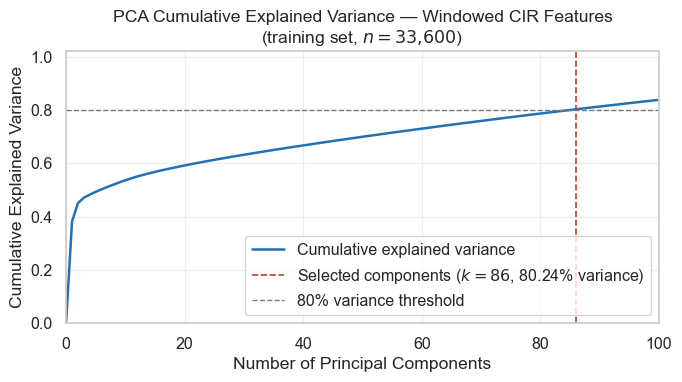

Variance at 86:  0.8022
Variance at 100: 0.8376


In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Refit full PCA on training CIR only — for visualisation, not modelling
n = len(selected_features)
cir_train = X_train_raw[:, n:]                        # (33600, 200)
cir_scaled = StandardScaler().fit_transform(cir_train)

pca_full = PCA(n_components=200, random_state=42)
pca_full.fit(cir_scaled)
cumvar = pca_full.explained_variance_ratio_.cumsum()

# Prepend (0, 0) so the line starts from the origin
x_vals = [0] + list(range(1, 201))
y_vals = [0] + list(cumvar)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_vals, y_vals, color='#2171B5', linewidth=1.8, label='Cumulative explained variance')

ax.axvline(86, linestyle='--', color='#C0392B', linewidth=1.2,
           label='Selected components ($k=86$, 80.24% variance)')
ax.axhline(0.80, linestyle='--', color='#717D7E', linewidth=1.0,
           label='80% variance threshold')

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Cumulative Explained Variance — Windowed CIR Features\n(training set, $n=33{,}600$)')
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../pca_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Variance at 86:  {cumvar[85]:.4f}")
print(f"Variance at 100: {cumvar[99]:.4f}")

DATA PROCESSING FOR REGRESSION MODELS

In [13]:
X_train_reg = np.hstack([X_train_classification, y_train.reshape(-1, 1)]) #appends NLOS back
X_test_reg = np.hstack([X_test_classification, y_test.reshape(-1, 1)]) #appends NLOS back

print(f"X_train_reg:  {X_train_reg.shape}")   # (33600, 103)
print(f"X_test_reg:  {X_test_reg.shape}")   # (8400, 103)
print(f"y_reg_train:  {y_reg_train.shape}")    # (33600,)
print(f"y_reg_test:   {y_reg_test.shape}")     # (8400,)


X_train_reg:  (33599, 103)
X_test_reg:  (8400, 103)
y_reg_train:  (33599,)
y_reg_test:   (8400,)
